# MACHINE LEARNING-DRIVEN PREDICTIVE RESOURCE ALLOCATION SYSTEM FOR ENERGY-EFFICIENT DATA CENTRE 

- This notebook details the steps and procedure undergone in developing model that can forecast workloads in datacenters. 
- The model(s) will be instrumental part in the ML powered resource allocator.
- The model training will employ an opensource dataset found on kaggle 
- *This dataset is designed for energy-efficient computational resource allocation in cloud service management systems*. 
- *It contains* **6,345** *samples with key cloud resource metrics, including*
  -  **CPU usage**
  -  **Memory usage**
  -  **Network utilization**
  -  **Disk I/O**
  -  **Energy consumption**
  -  **Service latency.**


# DATA PREPROCCESSING
- The dataset is loaded and inspected for any missing values, outliers, or inconsistencies.
- We will check feature importance and correlation to identify which features are most relevant for predicting the target variable (energy consumption).
- The features are normalized to ensure that they are on the same scale, which is crucial for many machine learning algorithms.

In [2]:
#Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocessing Steps:
1. **Loading the Dataset**: The dataset is loaded into a pandas DataFrame for analysis
2. **Handling Missing Values**: We check for any missing values in the dataset and decide on an appropriate strategy to handle them (e.g., imputation or removal).


In [3]:
#loading dataset
data = pd.read_csv('cloud_resource_allocation_dataset.csv')
data.head()

,CPU_Usage (%),Memory_Usage (MB),Network_Usage (MBps),Disk_IO (MBps),Energy_Consumption (Watts),Service_Latency (ms),Predicted_Workload (%),Workload_Type,Task_Priority,Optimized_Resource_Allocation
0,38.708611,1672.006565,299.849111,80.730345,63.962799,221.448909,53.347812,Medium,1,2
1,90.564288,4855.632861,369.691377,141.502156,439.095473,109.940476,26.121036,Low,0,1
2,70.879455,16066.646712,262.324202,113.595918,228.348794,47.072212,54.192928,Medium,1,3
3,58.879264,9975.816106,408.852148,185.145627,168.739194,246.531890,11.554386,Low,0,1
4,19.041678,11776.947010,363.856234,6.062739,302.752831,48.275457,37.985173,Medium,1,3


In [6]:
#checking for missing values and duplicates
print(data.isnull().sum())
print("Duplicates:", data.duplicated().sum())  

CPU_Usage (%)                    0
Memory_Usage (MB)                0
Network_Usage (MBps)             0
Disk_IO (MBps)                   0
Energy_Consumption (Watts)       0
Service_Latency (ms)             0
Predicted_Workload (%)           0
Workload_Type                    0
Task_Priority                    0
Optimized_Resource_Allocation    0
dtype: int64
Duplicates: 0


Great no missing values in the dataset.   
The target variable are Predicted_Workload and  Energy_Consumption. We will check the correlation of the features with these target variables to identify which features are most relevant for our predictive model.

In [21]:
data.describe()

,CPU_Usage (%),Memory_Usage (MB),Network_Usage (MBps),Disk_IO (MBps),Energy_Consumption (Watts),Service_Latency (ms),Predicted_Workload (%),Task_Priority,Optimized_Resource_Allocation
count,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000
mean,49.683017,8382.224282,257.145571,102.177142,271.986176,126.966980,52.369345,0.992750,2.652167
std,26.032643,4557.962792,141.487996,57.433787,129.227886,70.438630,27.536769,0.794018,1.156247
min,5.001047,512.838469,10.123703,1.009577,50.030374,5.001356,5.001590,0.000000,1.000000
25%,26.959577,4480.900871,134.239390,52.758394,160.241097,65.430779,28.752284,0.000000,2.000000
50%,49.745729,8307.389462,258.288764,102.731599,271.637727,127.637742,52.079056,1.000000,3.000000
75%,72.144039,12338.746984,380.007717,151.086171,383.446963,187.232105,76.493893,2.000000,3.000000
max,94.974591,16378.813114,499.963165,199.980294,499.879438,249.948396,99.997354,2.000000,5.000000


### Exploratory Data Analysis (EDA)
#### Identifying and Removing Outliers
- We will use box plots to identify outliers in the dataset.
- Outliers can skew the results of machine learning models, so we will remove any identified outliers to improve model performance.

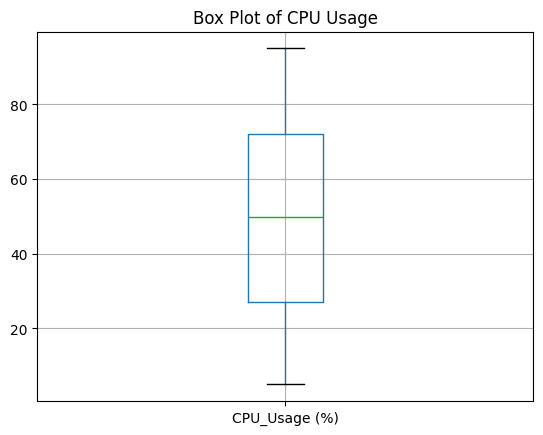

In [12]:
#id outlier in CPU_Usage
data.boxplot(column='CPU_Usage (%)')
plt.title('Box Plot of CPU Usage')
plt.show()

No outliers were identified in the column CPU_Usage, we will check for outliers in the other features as well.

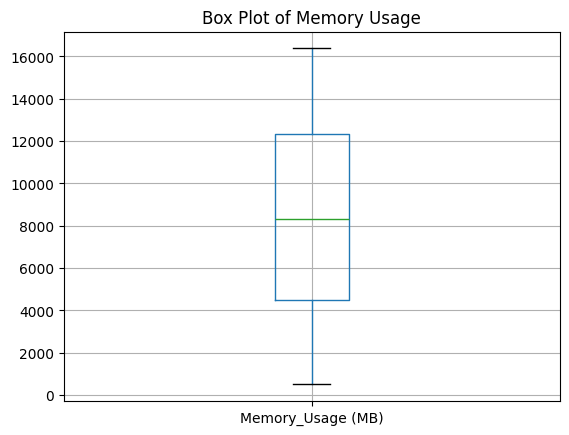

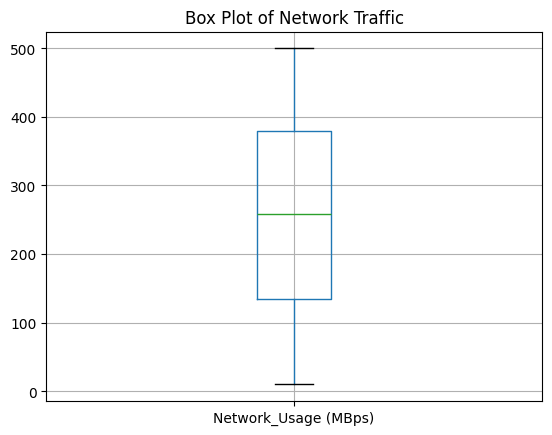

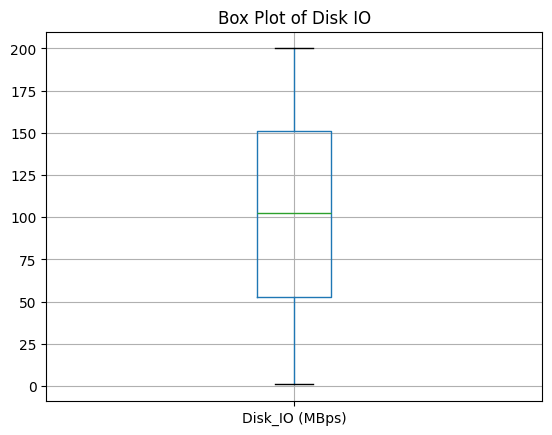

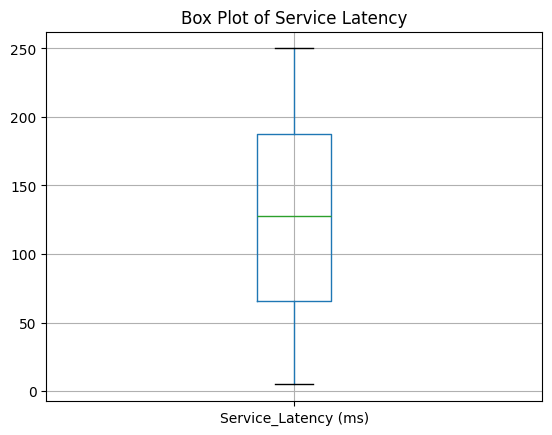

In [ ]:
#id outliers in Memory_Usage
data.boxplot(column='Memory_Usage (MB)')
plt.title('Box Plot of Memory Usage')
plt.show()

#id outliers in Network_Traffic
data.boxplot(column='Network_Usage (MBps)')
plt.title('Box Plot of Network Traffic')
plt.show()

#id outliers in Disk_IO
data.boxplot(column='Disk_IO (MBps)')
plt.title('Box Plot of Disk IO')
plt.show()

#id ouliers in service latency
data.boxplot(column='Service_Latency (ms)')
plt.title('Box Plot of Service Latency')
plt.show()

#id outliers in Task_Priority
data.boxplot(column='Task_Priority')
plt.title('Box Plot of Task Priority')
plt.show()


Task_Priority	Optimized_Resource_Allocation

From the box plots we can see that there are no outliers in the dataset, we will proceed to check the correlation of the features with the target variables Predicted_Workload and Energy_Consumption.

## FEATURE SELECTION
### Correlation Analysis
- We will compute the correlation of the features with the first target variable (predicted workload) to identify which features are most relevant for our predictive model.

In [23]:
#correlation analysis with target variable feature by featurePredicted_Workload
# CPU_Usage
correlation_cpu = data['CPU_Usage (%)'].corr(data['Predicted_Workload (%)'])
print("Correlation between CPU Usage and Predicted Workload:", correlation_cpu)
# Memory_Usage
correlation_memory = data['Memory_Usage (MB)'].corr(data['Predicted_Workload (%)'])
print("Correlation between Memory Usage and Predicted Workload:", correlation_memory)
# Network_Traffic
correlation_network = data['Network_Usage (MBps)'].corr(data['Predicted_Workload (%)'])
print("Correlation between Network Traffic and Predicted Workload:", correlation_network)
# Disk_IO
correlation_disk = data['Disk_IO (MBps)'].corr(data['Predicted_Workload (%)'])
print("Correlation between Disk IO and Predicted Workload:", correlation_disk)
# Service_Latency
correlation_latency = data['Service_Latency (ms)'].corr(data['Predicted_Workload (%)'])
print("Correlation between Service Latency and Predicted Workload:", correlation_latency)
# Task_Priority
correlation_priority = data['Task_Priority'].corr(data['Predicted_Workload (%)'])
print("Correlation between Task Priority and Predicted Workload:", correlation_priority)


Correlation between CPU Usage and Predicted Workload: 0.010812700838474494
Correlation between Memory Usage and Predicted Workload: 0.01749885080003546
Correlation between Network Traffic and Predicted Workload: 0.007397381866029689
Correlation between Disk IO and Predicted Workload: 0.0010875992847385516
Correlation between Service Latency and Predicted Workload: -0.003967167033810438
Correlation between Task Priority and Predicted Workload: 0.9424375379979065


**Correlation analysis revealed near-zero linear relationships between features and the target, consistent with independent random sampling in synthetic dataset generation. This motivates the use of non-linear models (Random Forest, Gradient Boosting) capable of detecting higher-order feature interactions.**

The absence of strong Pearson correlations suggests non-linear dependencies, which Spearman rank correlation and mutual information analysis will be used to further investigate."

In [22]:
#Spearman rank correlation
# CPU_Usage
spearman_cpu = data['CPU_Usage (%)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between CPU Usage and Predicted Workload:", spearman_cpu)
# Memory_Usage
spearman_memory = data['Memory_Usage (MB)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Memory Usage and Predicted Workload:", spearman_memory)
# Network_Traffic
spearman_network = data['Network_Usage (MBps)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Network Traffic and Predicted Workload:", spearman_network)
# Disk_IO
spearman_disk = data['Disk_IO (MBps)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Disk IO and Predicted Workload:", spearman_disk)
# Service_Latency
spearman_latency = data['Service_Latency (ms)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Service Latency and Predicted Workload:", spearman_latency)
# Task_Priority
spearman_priority = data['Task_Priority'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Task Priority and Predicted Workload:", spearman_priority)


Spearman Correlation between CPU Usage and Predicted Workload: 0.01079235853498574
Spearman Correlation between Memory Usage and Predicted Workload: 0.017454607445209835
Spearman Correlation between Network Traffic and Predicted Workload: 0.007431104482602062
Spearman Correlation between Disk IO and Predicted Workload: 0.0008468732922730954
Spearman Correlation between Service Latency and Predicted Workload: -0.003738671748478508
Spearman Correlation between Task Priority and Predicted Workload: 0.9417310392202164


### Correlation Analysis for Energy Consumption
- We will compute the correlation of the features with the second target variable (energy consumption) to identify which features are most relevant for our predictive model.

In [31]:
#id correlation with energy consumption
# CPU_Usage
correlation_cpu_energy = data['CPU_Usage (%)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between CPU Usage and Energy Consumption:", correlation_cpu_energy)
# Memory_Usage
correlation_memory_energy = data['Memory_Usage (MB)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Memory Usage and Energy Consumption:", correlation_memory_energy)
# Network_Traffic
correlation_network_energy = data['Network_Usage (MBps)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Network Traffic and Energy Consumption:", correlation_network_energy)
# Disk_IO
correlation_disk_energy = data['Disk_IO (MBps)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Disk IO and Energy Consumption:", correlation_disk_energy)
# Service_Latency
correlation_latency_energy = data['Service_Latency (ms)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Service Latency and Energy Consumption:", correlation_latency_energy)
# Task_Priority
correlation_priority_energy = data['Task_Priority'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Task Priority and Energy Consumption:", correlation_priority_energy)


Correlation between CPU Usage and Energy Consumption: -0.006486179141640983
Correlation between Memory Usage and Energy Consumption: 0.011942887697116758
Correlation between Network Traffic and Energy Consumption: -0.010255768006628814
Correlation between Disk IO and Energy Consumption: 0.004704904882153176
Correlation between Service Latency and Energy Consumption: -0.016778190560066755
Correlation between Task Priority and Energy Consumption: 0.00865381738571176


## Bitbrains GWA-T-12 fastStorage Single-Notebook Pipeline

The cells below are append-only and are designed for the local `fastStorage.zip` archive in this folder.

- They read the actual archive layout: `fastStorage/2013-8/*.csv`
- They use the Bitbrains trace schema instead of the earlier Kaggle-style schema above
- They keep everything in this single notebook and do not modify the earlier cells
- The loader auto-detects that the trace timestamps behave like Unix seconds even though the column label says `Timestamp [ms]`

Citation note: acknowledge Bitbrains IT Services and the @Large Research Group (TU Delft) in any publication or report that uses these traces, and cite the CCGrid 2015 paper.

In [ ]:
## LOading a single vm data from gwa-bitbrains.csv

In [ ]:
BB_COLUMN_MAP = {
    "Timestamp [ms]": "timestamp_raw",
    "CPU cores": "cpu_cores",
    "CPU capacity provisioned [MHZ]": "cpu_capacity_mhz",
    "CPU usage [MHZ]": "cpu_usage_mhz",
    "CPU usage [%]": "cpu_usage_pct",
    "Memory capacity provisioned [KB]": "mem_capacity_kb",
    "Memory usage [KB]": "mem_usage_kb",
    "Disk read throughput [KB/s]": "disk_read_kbps",
    "Disk write throughput [KB/s]": "disk_write_kbps",
    "Network received throughput [KB/s]": "net_rx_kbps",
    "Network transmitted throughput [KB/s]": "net_tx_kbps",
}

BB_EXPECTED_COLUMNS = [
    "timestamp_raw",
    "cpu_cores",
    "cpu_capacity_mhz",
    "cpu_usage_mhz",
    "cpu_usage_pct",
    "mem_capacity_kb",
    "mem_usage_kb",
    "disk_read_kbps",
    "disk_write_kbps",
    "net_rx_kbps",
    "net_tx_kbps",
]


def bb_normalize_trace_columns(columns):
    cleaned = [str(col).replace("\ufeff", "").strip() for col in columns]
    return [BB_COLUMN_MAP.get(col, col) for col in cleaned]


def bb_read_vm_trace_from_zip(zf, member_name):
    vm_id = Path(member_name).stem
    with zf.open(member_name) as fh:
        df = pd.read_csv(fh, sep=r";\s*", engine="python")

    df.columns = bb_normalize_trace_columns(df.columns)
    if "timestamp_raw" not in df.columns:
        df.columns = BB_EXPECTED_COLUMNS

    df = df[BB_EXPECTED_COLUMNS].copy()
    unit = "ms" if df["timestamp_raw"].max() > 10_000_000_000 else "s"

    df["timestamp"] = pd.to_datetime(df["timestamp_raw"], unit=unit, utc=True).dt.tz_localize(None)
    df["vm_id"] = vm_id
    df["disk_read_mbps"] = df["disk_read_kbps"] / 1024.0
    df["disk_write_mbps"] = df["disk_write_kbps"] / 1024.0
    return df


bb_raw_cache = BB_OUTPUT_DIR / "bitbrains_raw.pkl"

if bb_raw_cache.exists():
    bb_data = pd.read_pickle(bb_raw_cache)
    print(f"Loaded cached raw Bitbrains frame from {bb_raw_cache}")
else:
    bb_frames = []
    with zipfile.ZipFile(BB_ZIP_PATH) as zf:
        bb_members = sorted(
            name for name in zf.namelist()
            if name.startswith(BB_TRACE_PREFIX) and name.endswith(".csv")
        )
        print(f"Discovered {len(bb_members):,} VM trace files in {BB_ZIP_PATH.name}")
        for idx, member in enumerate(bb_members, start=1):
            bb_frames.append(bb_read_vm_trace_from_zip(zf, member))
            if idx % 250 == 0 or idx == len(bb_members):
                print(f"Loaded {idx:,}/{len(bb_members):,} VM files")

    bb_data = pd.concat(bb_frames, ignore_index=True)
    bb_data = bb_data.sort_values(["timestamp", "vm_id"]).reset_index(drop=True)
    bb_data.to_pickle(bb_raw_cache)
    print(f"Cached raw Bitbrains frame to {bb_raw_cache}")


print(f"Raw shape: {bb_data.shape}")
print(f"VM count: {bb_data['vm_id'].nunique():,}")
print(f"Time window: {bb_data['timestamp'].min()} -> {bb_data['timestamp'].max()}")
bb_data.head()

Discovered 1,250 VM trace files in fastStorage.zip


KeyboardInterrupt: 

In [ ]:
bb_data["energy_watts"] = BB_P_IDLE + (BB_P_MAX - BB_P_IDLE) * (bb_data["cpu_usage_pct"] / 100.0)
bb_data["hour"] = bb_data["timestamp"].dt.hour
bb_data["dayofweek"] = bb_data["timestamp"].dt.dayofweek
bb_data["mem_usage_gb"] = bb_data["mem_usage_kb"] / (1024 ** 2)
bb_data["net_total_kbps"] = bb_data["net_rx_kbps"] + bb_data["net_tx_kbps"]

print(bb_data[[
    "cpu_usage_pct",
    "cpu_usage_mhz",
    "mem_usage_kb",
    "disk_read_mbps",
    "disk_write_mbps",
    "net_rx_kbps",
    "net_tx_kbps",
    "energy_watts",
]].describe().T)

print("\nTop null counts")
print(bb_data.isna().sum().sort_values(ascending=False).head(15))

assert bb_data["cpu_usage_pct"].between(0, 100).all(), "CPU usage is outside the expected 0-100 range"
print("CPU usage range:", bb_data["cpu_usage_pct"].min(), "to", bb_data["cpu_usage_pct"].max())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_cols = [
    ("cpu_usage_pct", "CPU usage (%)"),
    ("mem_usage_gb", "Memory usage (GB)"),
    ("disk_read_mbps", "Disk read (MB/s)"),
    ("disk_write_mbps", "Disk write (MB/s)"),
    ("net_rx_kbps", "Net RX (KB/s)"),
    ("net_tx_kbps", "Net TX (KB/s)"),
]

for ax, (col, title) in zip(axes.flatten(), plot_cols):
    bb_data[col].clip(upper=bb_data[col].quantile(0.99)).hist(bins=50, ax=ax)
    ax.set_title(title)

plt.suptitle("Bitbrains fastStorage Feature Distributions (clipped at 99th percentile)")
plt.tight_layout()
plt.savefig(BB_OUTPUT_DIR / "fig_distributions.png", dpi=150)
plt.show()

In [ ]:
bb_hourly = bb_data.groupby("hour")["cpu_usage_pct"].mean()
bb_daily = bb_data.groupby("dayofweek")["cpu_usage_pct"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
bb_hourly.plot(ax=ax1, marker="o", title="Mean CPU Usage by Hour of Day")
ax1.set_ylabel("CPU Usage (%)")
bb_daily.plot(ax=ax2, marker="s", title="Mean CPU Usage by Day of Week")
ax2.set_xlabel("Day (0=Monday)")
plt.tight_layout()
plt.savefig(BB_OUTPUT_DIR / "fig_temporal_patterns.png", dpi=150)
plt.show()

bb_corr_cols = [
    "cpu_usage_pct",
    "cpu_usage_mhz",
    "mem_usage_kb",
    "disk_read_mbps",
    "disk_write_mbps",
    "net_rx_kbps",
    "net_tx_kbps",
    "energy_watts",
]

bb_corr = bb_data[bb_corr_cols].corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(bb_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix - Bitbrains fastStorage")
plt.tight_layout()
plt.savefig(BB_OUTPUT_DIR / "fig_correlation_heatmap.png", dpi=150)
plt.show()

bb_sample_vms = (
    bb_data[["vm_id"]]
    .drop_duplicates()
    .sample(3, random_state=BB_RANDOM_SEED)["vm_id"]
    .tolist()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
for ax, vm_id in zip(axes, bb_sample_vms):
    subset = bb_data.loc[bb_data["vm_id"] == vm_id].sort_values("timestamp")
    ax.plot(subset["timestamp"], subset["cpu_usage_pct"], linewidth=0.8)
    ax.set_title(f"VM: {vm_id}")
    ax.set_ylabel("CPU %")

plt.suptitle("CPU Utilisation Traces - Three Representative VMs")
plt.tight_layout()
plt.savefig(BB_OUTPUT_DIR / "fig_vm_profiles.png", dpi=150)
plt.show()

In [ ]:
def bb_preprocess_vm(vm_frame):
    work = vm_frame.sort_values("timestamp").copy()
    work = work.drop(columns=[col for col in ["vm_id", "timestamp_raw"] if col in work.columns])
    work = work.set_index("timestamp")
    work = work.resample("5min").mean(numeric_only=True)
    work = work.ffill(limit=3).dropna()

    work["mem_util_ratio"] = work["mem_usage_kb"] / work["mem_capacity_kb"]
    work["disk_io_total_mbps"] = work["disk_read_mbps"] + work["disk_write_mbps"]
    work["net_total_kbps"] = work["net_rx_kbps"] + work["net_tx_kbps"]

    for col in ["cpu_usage_pct", "mem_util_ratio", "disk_io_total_mbps"]:
        work[f"{col}_roll5_mean"] = work[col].rolling(5).mean()
        work[f"{col}_roll15_mean"] = work[col].rolling(15).mean()
        work[f"{col}_roll5_std"] = work[col].rolling(5).std()

    for lag in [1, 3, 5]:
        work[f"cpu_lag{lag}"] = work["cpu_usage_pct"].shift(lag)
        work[f"mem_lag{lag}"] = work["mem_util_ratio"].shift(lag)

    work["hour_sin"] = np.sin(2 * np.pi * work.index.hour / 24)
    work["hour_cos"] = np.cos(2 * np.pi * work.index.hour / 24)
    work["dow_sin"] = np.sin(2 * np.pi * work.index.dayofweek / 7)
    work["dow_cos"] = np.cos(2 * np.pi * work.index.dayofweek / 7)

    work["energy_watts"] = BB_P_IDLE + (BB_P_MAX - BB_P_IDLE) * (work["cpu_usage_pct"] / 100.0)
    work["target_cpu_t5"] = work["cpu_usage_pct"].shift(-1)
    return work.dropna()


bb_processed_cache = BB_OUTPUT_DIR / "bitbrains_processed.pkl"

if bb_processed_cache.exists():
    bb_full = pd.read_pickle(bb_processed_cache)
    print(f"Loaded cached processed frame from {bb_processed_cache}")
else:
    bb_processed_frames = []
    for idx, (vm_id, group) in enumerate(bb_data.groupby("vm_id"), start=1):
        proc = bb_preprocess_vm(group)
        proc["vm_id"] = vm_id
        bb_processed_frames.append(proc.reset_index())
        if idx % 250 == 0 or idx == bb_data["vm_id"].nunique():
            print(f"Processed {idx:,}/{bb_data['vm_id'].nunique():,} VMs")

    bb_full = pd.concat(bb_processed_frames, ignore_index=True)
    bb_full = bb_full.sort_values(["timestamp", "vm_id"]).reset_index(drop=True)
    bb_full.to_pickle(bb_processed_cache)
    print(f"Cached processed frame to {bb_processed_cache}")


print(f"Processed shape: {bb_full.shape}")
print(f"Processed columns: {len(bb_full.columns)}")
bb_full.head()

In [ ]:
def bb_time_split(frame, train_frac=0.70, val_frac=0.15):
    unique_ts = np.sort(frame["timestamp"].unique())
    train_idx = max(1, int(len(unique_ts) * train_frac)) - 1
    val_idx = max(train_idx + 1, int(len(unique_ts) * (train_frac + val_frac))) - 1

    train_cut = unique_ts[train_idx]
    val_cut = unique_ts[val_idx]

    train = frame.loc[frame["timestamp"] <= train_cut].copy()
    val = frame.loc[(frame["timestamp"] > train_cut) & (frame["timestamp"] <= val_cut)].copy()
    test = frame.loc[frame["timestamp"] > val_cut].copy()
    return train, val, test, train_cut, val_cut


bb_train, bb_val, bb_test, bb_train_cut, bb_val_cut = bb_time_split(bb_full)

BB_FEATURE_COLS = [
    col for col in bb_full.columns
    if col not in {"timestamp", "vm_id", "target_cpu_t5", "energy_watts", "cpu_usage_pct"}
]
BB_TARGET_S1 = "target_cpu_t5"
BB_TARGET_S2 = "energy_watts"

bb_scaler_tree = StandardScaler()
bb_X_train_tree = bb_scaler_tree.fit_transform(bb_train[BB_FEATURE_COLS])
bb_X_val_tree = bb_scaler_tree.transform(bb_val[BB_FEATURE_COLS])
bb_X_test_tree = bb_scaler_tree.transform(bb_test[BB_FEATURE_COLS])

bb_scaler_lstm = MinMaxScaler()
bb_scaler_lstm.fit(bb_train[BB_FEATURE_COLS])

joblib.dump(bb_scaler_tree, BB_OUTPUT_DIR / "scaler_tree.pkl")
joblib.dump(bb_scaler_lstm, BB_OUTPUT_DIR / "scaler_lstm.pkl")

print(f"Train split: {bb_train.shape}")
print(f"Validation split: {bb_val.shape}")
print(f"Test split: {bb_test.shape}")
print(f"Train cutoff: {bb_train_cut}")
print(f"Validation cutoff: {bb_val_cut}")
print(f"Feature count: {len(BB_FEATURE_COLS)}")

In [ ]:
bb_y_train_s1 = bb_train[BB_TARGET_S1].to_numpy()
bb_y_val_s1 = bb_val[BB_TARGET_S1].to_numpy()
bb_y_test_s1 = bb_test[BB_TARGET_S1].to_numpy()

bb_stage1_results = []
bb_stage1_models = {}

bb_rf_s1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=BB_RANDOM_SEED,
)
bb_rf_s1.fit(bb_X_train_tree, bb_y_train_s1)

bb_rf_val_pred = bb_rf_s1.predict(bb_X_val_tree)
bb_rf_test_pred = bb_rf_s1.predict(bb_X_test_tree)
bb_stage1_results.append(bb_report_metrics(bb_y_test_s1, bb_rf_test_pred, "Random Forest"))
bb_stage1_models["Random Forest"] = bb_rf_s1

bb_rf_tree_preds = np.stack([tree.predict(bb_X_test_tree) for tree in bb_rf_s1.estimators_])
bb_pi_lower = np.percentile(bb_rf_tree_preds, 5, axis=0)
bb_pi_upper = np.percentile(bb_rf_tree_preds, 95, axis=0)
bb_rf_coverage = np.mean((bb_y_test_s1 >= bb_pi_lower) & (bb_y_test_s1 <= bb_pi_upper))
print(f"Random Forest 90% empirical PI coverage: {bb_rf_coverage:.3f}")

if BB_HAS_LGB:
    bb_param_dist = {
        "n_estimators": [100, 200, 400],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [4, 6, 8, -1],
        "num_leaves": [31, 63, 127],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
    }

    bb_tscv = TimeSeriesSplit(n_splits=3)
    bb_lgb_search = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=BB_RANDOM_SEED, n_jobs=-1),
        param_distributions=bb_param_dist,
        n_iter=BB_LGB_SEARCH_ITER,
        cv=bb_tscv,
        scoring="neg_mean_absolute_error",
        random_state=BB_RANDOM_SEED,
        n_jobs=-1,
    )
    bb_lgb_search.fit(bb_X_train_tree, bb_y_train_s1)

    bb_lgb_s1 = bb_lgb_search.best_estimator_
    bb_lgb_test_pred = bb_lgb_s1.predict(bb_X_test_tree)
    bb_stage1_results.append(bb_report_metrics(bb_y_test_s1, bb_lgb_test_pred, "LightGBM"))
    bb_stage1_models["LightGBM"] = bb_lgb_s1
    print("Best LightGBM params:", bb_lgb_search.best_params_)
else:
    print("LightGBM is not installed, so the notebook will chain from the Random Forest baseline.")

bb_stage1_results_df = pd.DataFrame(bb_stage1_results).sort_values("rmse").reset_index(drop=True)
bb_stage1_chain_name = bb_stage1_results_df.loc[0, "model"]
bb_stage1_chain_model = bb_stage1_models[bb_stage1_chain_name]

joblib.dump(bb_stage1_chain_model, BB_OUTPUT_DIR / "stage1_chain_model.pkl")
bb_stage1_results_df.to_csv(BB_OUTPUT_DIR / "stage1_results.csv", index=False)

print(f"Stage 1 chaining model: {bb_stage1_chain_name}")
bb_stage1_results_df

In [ ]:
def bb_make_sequences_by_vm(split_df, feature_cols, target_col, scaler, seq_len):
    X_seq, y_seq = [], []
    split_df = split_df.sort_values(["vm_id", "timestamp"])

    for _, group in split_df.groupby("vm_id"):
        if len(group) <= seq_len:
            continue

        X_group = scaler.transform(group[feature_cols])
        y_group = group[target_col].to_numpy()
        for i in range(len(group) - seq_len):
            X_seq.append(X_group[i:i + seq_len])
            y_seq.append(y_group[i + seq_len])

    return np.array(X_seq), np.array(y_seq)


if BB_RUN_LSTM and BB_HAS_TF:
    tf.random.set_seed(BB_RANDOM_SEED)

    bb_X_tr_seq, bb_y_tr_seq = bb_make_sequences_by_vm(bb_train, BB_FEATURE_COLS, BB_TARGET_S1, bb_scaler_lstm, BB_SEQ_LEN)
    bb_X_vl_seq, bb_y_vl_seq = bb_make_sequences_by_vm(bb_val, BB_FEATURE_COLS, BB_TARGET_S1, bb_scaler_lstm, BB_SEQ_LEN)
    bb_X_te_seq, bb_y_te_seq = bb_make_sequences_by_vm(bb_test, BB_FEATURE_COLS, BB_TARGET_S1, bb_scaler_lstm, BB_SEQ_LEN)

    bb_lstm_s1 = Sequential([
        LSTM(64, return_sequences=True, input_shape=(BB_SEQ_LEN, len(BB_FEATURE_COLS))),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(1),
    ])
    bb_lstm_s1.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae")

    bb_es = EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")
    bb_history = bb_lstm_s1.fit(
        bb_X_tr_seq,
        bb_y_tr_seq,
        validation_data=(bb_X_vl_seq, bb_y_vl_seq),
        epochs=100,
        batch_size=64,
        callbacks=[bb_es],
        verbose=1,
    )

    plt.figure(figsize=(10, 4))
    plt.plot(bb_history.history["loss"], label="Train MAE")
    plt.plot(bb_history.history["val_loss"], label="Val MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("LSTM Stage 1 Training History")
    plt.legend()
    plt.tight_layout()
    plt.savefig(BB_OUTPUT_DIR / "fig_lstm_training_history.png", dpi=150)
    plt.show()

    bb_lstm_test_pred = bb_lstm_s1.predict(bb_X_te_seq).flatten()
    bb_lstm_metrics = bb_report_metrics(bb_y_te_seq, bb_lstm_test_pred, "LSTM")
    bb_stage1_results_df = pd.concat([bb_stage1_results_df, pd.DataFrame([bb_lstm_metrics])], ignore_index=True)
    bb_stage1_results_df = bb_stage1_results_df.sort_values("rmse").reset_index(drop=True)
    bb_stage1_results_df.to_csv(BB_OUTPUT_DIR / "stage1_results.csv", index=False)
    bb_lstm_s1.save(BB_OUTPUT_DIR / "lstm_stage1.keras")
else:
    print("Skipping LSTM. Set BB_RUN_LSTM = True and install TensorFlow if you want the sequence model benchmark.")

bb_stage1_results_df

In [ ]:
bb_s1_train_pred = bb_stage1_chain_model.predict(bb_X_train_tree)
bb_s1_val_pred = bb_stage1_chain_model.predict(bb_X_val_tree)
bb_s1_test_pred = bb_stage1_chain_model.predict(bb_X_test_tree)

bb_X_train_s2 = np.hstack([bb_X_train_tree, bb_s1_train_pred.reshape(-1, 1)])
bb_X_val_s2 = np.hstack([bb_X_val_tree, bb_s1_val_pred.reshape(-1, 1)])
bb_X_test_s2 = np.hstack([bb_X_test_tree, bb_s1_test_pred.reshape(-1, 1)])

bb_y_train_s2 = bb_train[BB_TARGET_S2].to_numpy()
bb_y_val_s2 = bb_val[BB_TARGET_S2].to_numpy()
bb_y_test_s2 = bb_test[BB_TARGET_S2].to_numpy()

if BB_HAS_LGB:
    bb_s2_params = bb_lgb_search.best_params_ if "bb_lgb_search" in globals() else {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 6,
        "num_leaves": 63,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    }
    bb_s2_model = lgb.LGBMRegressor(**bb_s2_params, random_state=BB_RANDOM_SEED, n_jobs=-1)
    bb_s2_model.fit(
        bb_X_train_s2,
        bb_y_train_s2,
        eval_set=[(bb_X_val_s2, bb_y_val_s2)],
        callbacks=[lgb.early_stopping(20), lgb.log_evaluation(50)],
    )
    bb_stage2_model_name = "LightGBM"
else:
    bb_s2_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        n_jobs=-1,
        random_state=BB_RANDOM_SEED,
    )
    bb_s2_model.fit(bb_X_train_s2, bb_y_train_s2)
    bb_stage2_model_name = "Random Forest"

bb_s2_test_pred_pipeline = bb_s2_model.predict(bb_X_test_s2)
bb_stage2_pipeline_metrics = bb_report_metrics(bb_y_test_s2, bb_s2_test_pred_pipeline, f"Stage 2 Pipeline ({bb_stage2_model_name})")

bb_X_train_s2_oracle = np.hstack([bb_X_train_tree, bb_train["cpu_usage_pct"].to_numpy().reshape(-1, 1)])
bb_X_val_s2_oracle = np.hstack([bb_X_val_tree, bb_val["cpu_usage_pct"].to_numpy().reshape(-1, 1)])
bb_X_test_s2_oracle = np.hstack([bb_X_test_tree, bb_test["cpu_usage_pct"].to_numpy().reshape(-1, 1)])

if BB_HAS_LGB:
    bb_s2_oracle = lgb.LGBMRegressor(**bb_s2_params, random_state=BB_RANDOM_SEED, n_jobs=-1)
else:
    bb_s2_oracle = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        n_jobs=-1,
        random_state=BB_RANDOM_SEED,
    )

bb_s2_oracle.fit(bb_X_train_s2_oracle, bb_y_train_s2)
bb_s2_oracle_pred = bb_s2_oracle.predict(bb_X_test_s2_oracle)
bb_stage2_oracle_metrics = bb_report_metrics(bb_y_test_s2, bb_s2_oracle_pred, "Stage 2 Oracle")

bb_error_propagation_cost = bb_stage2_pipeline_metrics["rmse"] - bb_stage2_oracle_metrics["rmse"]
print(f"Error propagation cost: +{bb_error_propagation_cost:.4f} RMSE Watts")


def bb_predict_energy(feature_frame):
    x_scaled = bb_scaler_tree.transform(feature_frame[BB_FEATURE_COLS])
    cpu_pred = bb_stage1_chain_model.predict(x_scaled)
    x_stage2 = np.hstack([x_scaled, cpu_pred.reshape(-1, 1)])
    energy_pred = bb_s2_model.predict(x_stage2)
    return cpu_pred, energy_pred


bb_pipeline_summary = pd.DataFrame({
    "metric": [
        "Stage 1 RMSE (CPU %)",
        "Stage 1 MAE (CPU %)",
        "Stage 1 R2",
        "Stage 2 RMSE (Watts) - Pipeline",
        "Stage 2 RMSE (Watts) - Oracle",
        "Error propagation cost (Watts RMSE)",
    ],
    "value": [
        float(bb_stage1_results_df.loc[bb_stage1_results_df["model"] == bb_stage1_chain_name, "rmse"].iloc[0]),
        float(bb_stage1_results_df.loc[bb_stage1_results_df["model"] == bb_stage1_chain_name, "mae"].iloc[0]),
        float(bb_stage1_results_df.loc[bb_stage1_results_df["model"] == bb_stage1_chain_name, "r2"].iloc[0]),
        bb_stage2_pipeline_metrics["rmse"],
        bb_stage2_oracle_metrics["rmse"],
        bb_error_propagation_cost,
    ],
})

bb_pipeline_summary.to_csv(BB_OUTPUT_DIR / "pipeline_final_results.csv", index=False)
joblib.dump(bb_stage1_chain_model, BB_OUTPUT_DIR / "model_stage1_prod.pkl")
joblib.dump(bb_s2_model, BB_OUTPUT_DIR / "model_stage2_prod.pkl")
joblib.dump(bb_scaler_tree, BB_OUTPUT_DIR / "scaler_prod.pkl")
(BB_OUTPUT_DIR / "feature_cols.json").write_text(json.dumps(BB_FEATURE_COLS, indent=2))

print(f"Stage 1 chain model saved: {BB_OUTPUT_DIR / 'model_stage1_prod.pkl'}")
print(f"Stage 2 model saved: {BB_OUTPUT_DIR / 'model_stage2_prod.pkl'}")
print(f"Scaler saved: {BB_OUTPUT_DIR / 'scaler_prod.pkl'}")
print("\nOptional Multipass fine-tuning can be added later once ./data/prometheus_exports/cluster_metrics.csv exists.")

bb_pipeline_summary

## Bitbrains Restart Point (Use This Section)

The notebook already contains the full single-notebook Bitbrains pipeline below your original work. These final cells make the start point explicit.

- The local archive expected is `./fastStorage.zip`
- The trace folder inside the archive is `fastStorage/2013-8/`
- Run the next code cell first if you want the dataset extracted to disk before running the Bitbrains pipeline cells above
- If you prefer, the earlier Bitbrains loader can also read directly from the zip without extraction


In [ ]:
from pathlib import Path
import zipfile

BB_ZIP_PATH = Path("./fastStorage.zip")
BB_EXTRACT_ROOT = Path("./fastStorage")
BB_EXPECTED_DIR = BB_EXTRACT_ROOT / "2013-8"

if not BB_ZIP_PATH.exists():
    raise FileNotFoundError(f"Could not find {BB_ZIP_PATH.resolve()}")

if BB_EXPECTED_DIR.exists():
    csv_count = len(list(BB_EXPECTED_DIR.glob("*.csv")))
    print(f"Dataset already extracted: {BB_EXPECTED_DIR} | CSV files: {csv_count}")
else:
    with zipfile.ZipFile(BB_ZIP_PATH, "r") as zf:
        zf.extractall(".")
    csv_count = len(list(BB_EXPECTED_DIR.glob("*.csv")))
    print(f"Extracted dataset to: {BB_EXPECTED_DIR} | CSV files: {csv_count}")

assert BB_EXPECTED_DIR.exists(), "Expected extracted folder fastStorage/2013-8 was not created"
assert csv_count > 0, "No CSV trace files were found after extraction"


### What To Run Next

After the extraction cell:

1. Run the earlier markdown heading `## Bitbrains GWA-T-12 fastStorage Single-Notebook Pipeline`
2. Then run the Bitbrains code cells in order from imports to the final pipeline summary cell
3. Leave `BB_RUN_LSTM = False` unless you specifically want the LSTM benchmark and TensorFlow is installed

If you want, I can also append one more small section later that switches the existing loader from zip-reading to extracted-folder reading only.


## Bitbrains Low-Memory Single-VM Pipeline

Use this section if the full multi-VM workflow is too heavy for memory.

Methodology statement:

"To maintain experimental tractability while preserving the integrity of real-world telemetry, a single representative VM trace was selected from the GWA-T-12 fastStorage dataset. Selection criteria required a minimum of 500 timesteps, a CPU utilisation standard deviation exceeding 10%, and a mean utilisation between 20% and 80% to ensure the trace captured meaningful workload variability. This approach is consistent with single-trace evaluation methodology used in prior VM workload forecasting studies."

This low-memory path does two things differently:

- It scans all VM files only to compute lightweight selection statistics
- It loads only one chosen VM into the modeling pipeline

In [ ]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import lightgbm as lgb
    BB_SINGLE_HAS_LGB = True
except ImportError:
    lgb = None
    BB_SINGLE_HAS_LGB = False

BB_SINGLE_RANDOM_SEED = 42
BB_SINGLE_P_IDLE = 100
BB_SINGLE_P_MAX = 200
BB_SINGLE_OUTPUT_DIR = Path("./outputs/bitbrains_single_vm")
BB_SINGLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(BB_SINGLE_RANDOM_SEED)

BB_SINGLE_COLUMN_MAP = {
    "Timestamp [ms]": "timestamp_raw",
    "CPU cores": "cpu_cores",
    "CPU capacity provisioned [MHZ]": "cpu_capacity_mhz",
    "CPU usage [MHZ]": "cpu_usage_mhz",
    "CPU usage [%]": "cpu_usage_pct",
    "Memory capacity provisioned [KB]": "mem_capacity_kb",
    "Memory usage [KB]": "mem_usage_kb",
    "Disk read throughput [KB/s]": "disk_read_kbps",
    "Disk write throughput [KB/s]": "disk_write_kbps",
    "Network received throughput [KB/s]": "net_rx_kbps",
    "Network transmitted throughput [KB/s]": "net_tx_kbps",
}

def bb_single_normalize_columns(df):
    df = df.copy()
    df.columns = [BB_SINGLE_COLUMN_MAP.get(str(col).replace("\ufeff", "").strip(), str(col).strip()) for col in df.columns]
    return df

def bb_single_resolve_data_dir():
    candidates = [
        Path("./data/fastStorage"),
        Path("./fastStorage/2013-8"),
        Path("./fastStorage"),
    ]
    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("*.csv")):
            return candidate
    raise FileNotFoundError("No extracted fastStorage CSV directory was found. Run the bbextract cell first.")

def bb_single_load_trace(csv_path):
    df = pd.read_csv(csv_path, sep=r";\s*", engine="python")
    df = bb_single_normalize_columns(df)
    unit = "ms" if df["timestamp_raw"].max() > 10_000_000_000 else "s"
    df["timestamp"] = pd.to_datetime(df["timestamp_raw"], unit=unit)
    df["disk_read_mbps"] = df["disk_read_kbps"] / 1024.0
    df["disk_write_mbps"] = df["disk_write_kbps"] / 1024.0
    return df.sort_values("timestamp").reset_index(drop=True)

def bb_single_report_metrics(y_true, y_pred, label):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    print(f"{label} | RMSE={rmse:.4f} | MAE={mae:.4f} | R2={r2:.4f}")
    return {"model": label, "rmse": rmse, "mae": mae, "r2": r2}

BB_SINGLE_DATA_DIR = bb_single_resolve_data_dir()
print(f"Using extracted CSV folder: {BB_SINGLE_DATA_DIR.resolve()}")
print(f"LightGBM available: {BB_SINGLE_HAS_LGB}")

In [ ]:
bb_single_summaries = []

for csv_file in sorted(BB_SINGLE_DATA_DIR.glob("*.csv")):
    vm_df = bb_single_load_trace(csv_file)
    bb_single_summaries.append({
        "vm_id": csv_file.stem,
        "rows": len(vm_df),
        "cpu_mean": vm_df["cpu_usage_pct"].mean(),
        "cpu_std": vm_df["cpu_usage_pct"].std(),
        "cpu_max": vm_df["cpu_usage_pct"].max(),
        "nulls": int(vm_df.isnull().sum().sum()),
    })

bb_single_summary_df = pd.DataFrame(bb_single_summaries).sort_values(["cpu_std", "rows"], ascending=[False, False]).reset_index(drop=True)

bb_single_candidates = bb_single_summary_df.loc[
    (bb_single_summary_df["rows"] > 500) &
    (bb_single_summary_df["cpu_std"] > 10) &
    (bb_single_summary_df["cpu_mean"].between(20, 80)) &
    (bb_single_summary_df["nulls"] == 0)
].copy()

print(f"Total VM files scanned: {len(bb_single_summary_df)}")
print(f"Eligible single-VM candidates: {len(bb_single_candidates)}")
display(bb_single_summary_df.head(20))

### Choose One Representative VM

Selection rule used here:

- `rows > 500`
- `cpu_std > 10`
- `20 <= cpu_mean <= 80`
- `nulls == 0`

Set `SELECTED_VM` manually if you want a specific trace from the candidate table. Otherwise the code auto-selects the best eligible VM ranked by CPU variability.

In [ ]:
SELECTED_VM = None

if SELECTED_VM is None:
    if len(bb_single_candidates) > 0:
        SELECTED_VM = bb_single_candidates.iloc[0]["vm_id"]
    else:
        SELECTED_VM = bb_single_summary_df.iloc[0]["vm_id"]

bb_single_path = BB_SINGLE_DATA_DIR / f"{SELECTED_VM}.csv"
bb_single_data = bb_single_load_trace(bb_single_path)
bb_single_data["energy_watts"] = BB_SINGLE_P_IDLE + (BB_SINGLE_P_MAX - BB_SINGLE_P_IDLE) * (bb_single_data["cpu_usage_pct"] / 100.0)

print(f"Loaded VM: {SELECTED_VM} | Rows: {len(bb_single_data)}")
print(bb_single_data[["timestamp", "cpu_usage_pct", "mem_usage_kb", "disk_read_mbps", "disk_write_mbps", "net_rx_kbps", "net_tx_kbps"]].head())

In [ ]:
bb_single_data["hour"] = bb_single_data["timestamp"].dt.hour
bb_single_data["dayofweek"] = bb_single_data["timestamp"].dt.dayofweek
bb_single_data["mem_usage_gb"] = bb_single_data["mem_usage_kb"] / (1024 ** 2)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
bb_single_data["cpu_usage_pct"].hist(bins=40, ax=axes[0, 0])
axes[0, 0].set_title("CPU usage (%)")
bb_single_data["mem_usage_gb"].hist(bins=40, ax=axes[0, 1])
axes[0, 1].set_title("Memory usage (GB)")
bb_single_data["disk_read_mbps"].clip(upper=bb_single_data["disk_read_mbps"].quantile(0.99)).hist(bins=40, ax=axes[1, 0])
axes[1, 0].set_title("Disk read (MB/s)")
bb_single_data["disk_write_mbps"].clip(upper=bb_single_data["disk_write_mbps"].quantile(0.99)).hist(bins=40, ax=axes[1, 1])
axes[1, 1].set_title("Disk write (MB/s)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(bb_single_data["timestamp"], bb_single_data["cpu_usage_pct"], linewidth=0.8)
plt.title(f"CPU utilisation trace for VM {SELECTED_VM}")
plt.ylabel("CPU %")
plt.tight_layout()
plt.show()

bb_single_corr_cols = ["cpu_usage_pct", "cpu_usage_mhz", "mem_usage_kb", "disk_read_mbps", "disk_write_mbps", "net_rx_kbps", "net_tx_kbps", "energy_watts"]
plt.figure(figsize=(10, 7))
sns.heatmap(bb_single_data[bb_single_corr_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Spearman correlation matrix for VM {SELECTED_VM}")
plt.tight_layout()
plt.show()

In [ ]:
def bb_single_preprocess(df):
    work = df.copy().sort_values("timestamp").set_index("timestamp")
    work = work.resample("5min").mean(numeric_only=True)
    work = work.ffill(limit=3).dropna()

    work["mem_util_ratio"] = work["mem_usage_kb"] / work["mem_capacity_kb"]
    work["disk_io_total_mbps"] = work["disk_read_mbps"] + work["disk_write_mbps"]
    work["net_total_kbps"] = work["net_rx_kbps"] + work["net_tx_kbps"]

    for col in ["cpu_usage_pct", "mem_util_ratio", "disk_io_total_mbps"]:
        work[f"{col}_roll5_mean"] = work[col].rolling(5).mean()
        work[f"{col}_roll15_mean"] = work[col].rolling(15).mean()
        work[f"{col}_roll5_std"] = work[col].rolling(5).std()

    for lag in [1, 3, 5]:
        work[f"cpu_lag{lag}"] = work["cpu_usage_pct"].shift(lag)
        work[f"mem_lag{lag}"] = work["mem_util_ratio"].shift(lag)

    work["hour_sin"] = np.sin(2 * np.pi * work.index.hour / 24)
    work["hour_cos"] = np.cos(2 * np.pi * work.index.hour / 24)
    work["dow_sin"] = np.sin(2 * np.pi * work.index.dayofweek / 7)
    work["dow_cos"] = np.cos(2 * np.pi * work.index.dayofweek / 7)
    work["energy_watts"] = BB_SINGLE_P_IDLE + (BB_SINGLE_P_MAX - BB_SINGLE_P_IDLE) * (work["cpu_usage_pct"] / 100.0)
    work["target_cpu_t5"] = work["cpu_usage_pct"].shift(-1)
    return work.dropna().reset_index()

bb_single_full = bb_single_preprocess(bb_single_data)
BB_SINGLE_FEATURE_COLS = [col for col in bb_single_full.columns if col not in {"timestamp", "target_cpu_t5", "energy_watts", "cpu_usage_pct"}]

n_rows = len(bb_single_full)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

bb_single_train = bb_single_full.iloc[:train_end].copy()
bb_single_val = bb_single_full.iloc[train_end:val_end].copy()
bb_single_test = bb_single_full.iloc[val_end:].copy()

bb_single_scaler = StandardScaler()
bb_single_X_train = bb_single_scaler.fit_transform(bb_single_train[BB_SINGLE_FEATURE_COLS])
bb_single_X_val = bb_single_scaler.transform(bb_single_val[BB_SINGLE_FEATURE_COLS])
bb_single_X_test = bb_single_scaler.transform(bb_single_test[BB_SINGLE_FEATURE_COLS])

bb_single_y_train_s1 = bb_single_train["target_cpu_t5"].to_numpy()
bb_single_y_val_s1 = bb_single_val["target_cpu_t5"].to_numpy()
bb_single_y_test_s1 = bb_single_test["target_cpu_t5"].to_numpy()

print(f"Processed rows: {len(bb_single_full)}")
print(f"Train/Val/Test: {len(bb_single_train)}, {len(bb_single_val)}, {len(bb_single_test)}")
print(f"Feature count: {len(BB_SINGLE_FEATURE_COLS)}")

In [ ]:
bb_single_stage1_results = []
bb_single_models = {}

bb_single_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=BB_SINGLE_RANDOM_SEED,
)
bb_single_rf.fit(bb_single_X_train, bb_single_y_train_s1)
bb_single_rf_test_pred = bb_single_rf.predict(bb_single_X_test)
bb_single_stage1_results.append(bb_single_report_metrics(bb_single_y_test_s1, bb_single_rf_test_pred, "Random Forest Stage 1"))
bb_single_models["Random Forest"] = bb_single_rf

if BB_SINGLE_HAS_LGB:
    bb_single_param_dist = {
        "n_estimators": [100, 200, 400],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [4, 6, 8, -1],
        "num_leaves": [31, 63, 127],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
    }
    bb_single_search = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=BB_SINGLE_RANDOM_SEED, n_jobs=-1),
        param_distributions=bb_single_param_dist,
        n_iter=12,
        cv=TimeSeriesSplit(n_splits=3),
        scoring="neg_mean_absolute_error",
        random_state=BB_SINGLE_RANDOM_SEED,
        n_jobs=-1,
    )
    bb_single_search.fit(bb_single_X_train, bb_single_y_train_s1)
    bb_single_lgb = bb_single_search.best_estimator_
    bb_single_lgb_test_pred = bb_single_lgb.predict(bb_single_X_test)
    bb_single_stage1_results.append(bb_single_report_metrics(bb_single_y_test_s1, bb_single_lgb_test_pred, "LightGBM Stage 1"))
    bb_single_models["LightGBM"] = bb_single_lgb
    print("Best LightGBM params:", bb_single_search.best_params_)

bb_single_stage1_df = pd.DataFrame(bb_single_stage1_results).sort_values("rmse").reset_index(drop=True)
bb_single_best_name = "LightGBM" if "LightGBM" in bb_single_models else "Random Forest"
bb_single_stage1_model = bb_single_models[bb_single_best_name]
print(f"Selected Stage 1 model: {bb_single_best_name}")
display(bb_single_stage1_df)

In [ ]:
bb_single_s1_train_pred = bb_single_stage1_model.predict(bb_single_X_train)
bb_single_s1_val_pred = bb_single_stage1_model.predict(bb_single_X_val)
bb_single_s1_test_pred = bb_single_stage1_model.predict(bb_single_X_test)

bb_single_X_train_s2 = np.hstack([bb_single_X_train, bb_single_s1_train_pred.reshape(-1, 1)])
bb_single_X_val_s2 = np.hstack([bb_single_X_val, bb_single_s1_val_pred.reshape(-1, 1)])
bb_single_X_test_s2 = np.hstack([bb_single_X_test, bb_single_s1_test_pred.reshape(-1, 1)])

bb_single_y_train_s2 = bb_single_train["energy_watts"].to_numpy()
bb_single_y_val_s2 = bb_single_val["energy_watts"].to_numpy()
bb_single_y_test_s2 = bb_single_test["energy_watts"].to_numpy()

if BB_SINGLE_HAS_LGB:
    bb_single_stage2 = lgb.LGBMRegressor(random_state=BB_SINGLE_RANDOM_SEED, n_jobs=-1)
    bb_single_stage2.fit(bb_single_X_train_s2, bb_single_y_train_s2)
else:
    bb_single_stage2 = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        n_jobs=-1,
        random_state=BB_SINGLE_RANDOM_SEED,
    )
    bb_single_stage2.fit(bb_single_X_train_s2, bb_single_y_train_s2)

bb_single_s2_pipeline_pred = bb_single_stage2.predict(bb_single_X_test_s2)
bb_single_stage2_pipeline_metrics = bb_single_report_metrics(bb_single_y_test_s2, bb_single_s2_pipeline_pred, "Stage 2 Pipeline")

bb_single_X_train_s2_oracle = np.hstack([bb_single_X_train, bb_single_train["cpu_usage_pct"].to_numpy().reshape(-1, 1)])
bb_single_X_test_s2_oracle = np.hstack([bb_single_X_test, bb_single_test["cpu_usage_pct"].to_numpy().reshape(-1, 1)])

if BB_SINGLE_HAS_LGB:
    bb_single_stage2_oracle = lgb.LGBMRegressor(random_state=BB_SINGLE_RANDOM_SEED, n_jobs=-1)
    bb_single_stage2_oracle.fit(bb_single_X_train_s2_oracle, bb_single_y_train_s2)
else:
    bb_single_stage2_oracle = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        n_jobs=-1,
        random_state=BB_SINGLE_RANDOM_SEED,
    )
    bb_single_stage2_oracle.fit(bb_single_X_train_s2_oracle, bb_single_y_train_s2)

bb_single_s2_oracle_pred = bb_single_stage2_oracle.predict(bb_single_X_test_s2_oracle)
bb_single_stage2_oracle_metrics = bb_single_report_metrics(bb_single_y_test_s2, bb_single_s2_oracle_pred, "Stage 2 Oracle")

bb_single_results_summary = pd.DataFrame({
    "metric": [
        "Selected VM",
        "Stage 1 model",
        "Stage 1 RMSE (CPU %)",
        "Stage 1 MAE (CPU %)",
        "Stage 1 R2",
        "Stage 2 RMSE (Watts) - Pipeline",
        "Stage 2 RMSE (Watts) - Oracle",
        "Error propagation cost (Watts RMSE)",
    ],
    "value": [
        SELECTED_VM,
        bb_single_best_name,
        float(bb_single_stage1_df.loc[0, "rmse"]),
        float(bb_single_stage1_df.loc[0, "mae"]),
        float(bb_single_stage1_df.loc[0, "r2"]),
        bb_single_stage2_pipeline_metrics["rmse"],
        bb_single_stage2_oracle_metrics["rmse"],
        bb_single_stage2_pipeline_metrics["rmse"] - bb_single_stage2_oracle_metrics["rmse"],
    ],
})

joblib.dump(bb_single_stage1_model, BB_SINGLE_OUTPUT_DIR / "stage1_single_vm.pkl")
joblib.dump(bb_single_stage2, BB_SINGLE_OUTPUT_DIR / "stage2_single_vm.pkl")
joblib.dump(bb_single_scaler, BB_SINGLE_OUTPUT_DIR / "scaler_single_vm.pkl")
bb_single_stage1_df.to_csv(BB_SINGLE_OUTPUT_DIR / "stage1_results.csv", index=False)
bb_single_results_summary.to_csv(BB_SINGLE_OUTPUT_DIR / "pipeline_summary.csv", index=False)

display(bb_single_results_summary)

### Run Order For This Low-Memory Path

Run these cells in order:

1. `bbextract`
2. `bbsingleimports`
3. `bbsinglescan`
4. `bbsingleload`
5. `bbsingleeda`
6. `bbsingleprep`
7. `bbsingletrain`
8. `bbsinglestage2`

If you want to force a different VM, edit `SELECTED_VM` in the `bbsingleload` cell before running it.

## Fast Fallback: First CSV Only

If you just want to move forward immediately, use this path instead of the heavier multi-VM cells.

- It picks the first extracted CSV in sorted order
- It sets `SELECTED_VM` and `bb_single_data` for the later single-VM cells
- It avoids the all-file scan completely

In [ ]:
BB_SINGLE_DATA_DIR = bb_single_resolve_data_dir()
BB_FIRST_VM_PATH = sorted(BB_SINGLE_DATA_DIR.glob("*.csv"))[0]
SELECTED_VM = BB_FIRST_VM_PATH.stem
bb_single_data = bb_single_load_trace(BB_FIRST_VM_PATH)
bb_single_data["energy_watts"] = BB_SINGLE_P_IDLE + (BB_SINGLE_P_MAX - BB_SINGLE_P_IDLE) * (bb_single_data["cpu_usage_pct"] / 100.0)

print(f"Loaded first CSV VM: {SELECTED_VM} | Rows: {len(bb_single_data)}")
print(f"Source file: {BB_FIRST_VM_PATH}")
bb_single_data.head()

## Univariate Analysis For The Selected VM

This section focuses on one variable at a time for the chosen trace, which is useful for describing the behavior of the VM before modeling.

In [ ]:
bb_uni_cols = [
    "cpu_usage_pct",
    "cpu_usage_mhz",
    "mem_usage_kb",
    "disk_read_mbps",
    "disk_write_mbps",
    "net_rx_kbps",
    "net_tx_kbps",
    "energy_watts",
]

bb_uni_summary = bb_single_data[bb_uni_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
print("Missing values by column:")
print(bb_single_data[bb_uni_cols].isnull().sum())
print("\nUnivariate summary statistics:")
display(bb_uni_summary)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flatten(), bb_uni_cols):
    bb_single_data[col].clip(upper=bb_single_data[col].quantile(0.99)).hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flatten(), bb_uni_cols):
    sns.boxplot(x=bb_single_data[col], ax=ax)
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(bb_single_data["timestamp"], bb_single_data["cpu_usage_pct"], linewidth=0.8)
plt.title(f"Selected VM CPU trace: {SELECTED_VM}")
plt.ylabel("CPU %")
plt.tight_layout()
plt.show()

### Fastest Run Order Now

Run these cells in order:

1. `bbextract`
2. `bbsingleimports`
3. `bbfirstload`
4. `bbuni`
5. `bbsingleprep`
6. `bbsingletrain`
7. `bbsinglestage2`

This skips the memory-heavier multi-VM concat path and also skips the candidate scan.